   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 34.4 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-03-29 07:41:00.088350: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774770060.287865      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774770060.348014      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774770060.840829      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774770060.840870      24 computation_placer.cc:1

🚀 Initializing SOTA Grid-Search Ensemble Engine...
✅ All Models Loaded Successfully!

🔍 PHASE 1: Auto-Optimizing Weights on Validation Set (38 cases)...


Extracting Val Features:   0%|          | 0/38 [00:00<?, ?it/s]

⚙️ Running 66 Mathematical Combinations...
🔥 Optimization Complete! Best Weights Found: DERNet=0.80, SegRes=0.00, AttUnet=0.20

🚀 PHASE 2: Evaluating Test Set (37 cases) with Optimized Weights & TTA...


Test Evaluation:   0%|          | 0/37 [00:00<?, ?it/s]

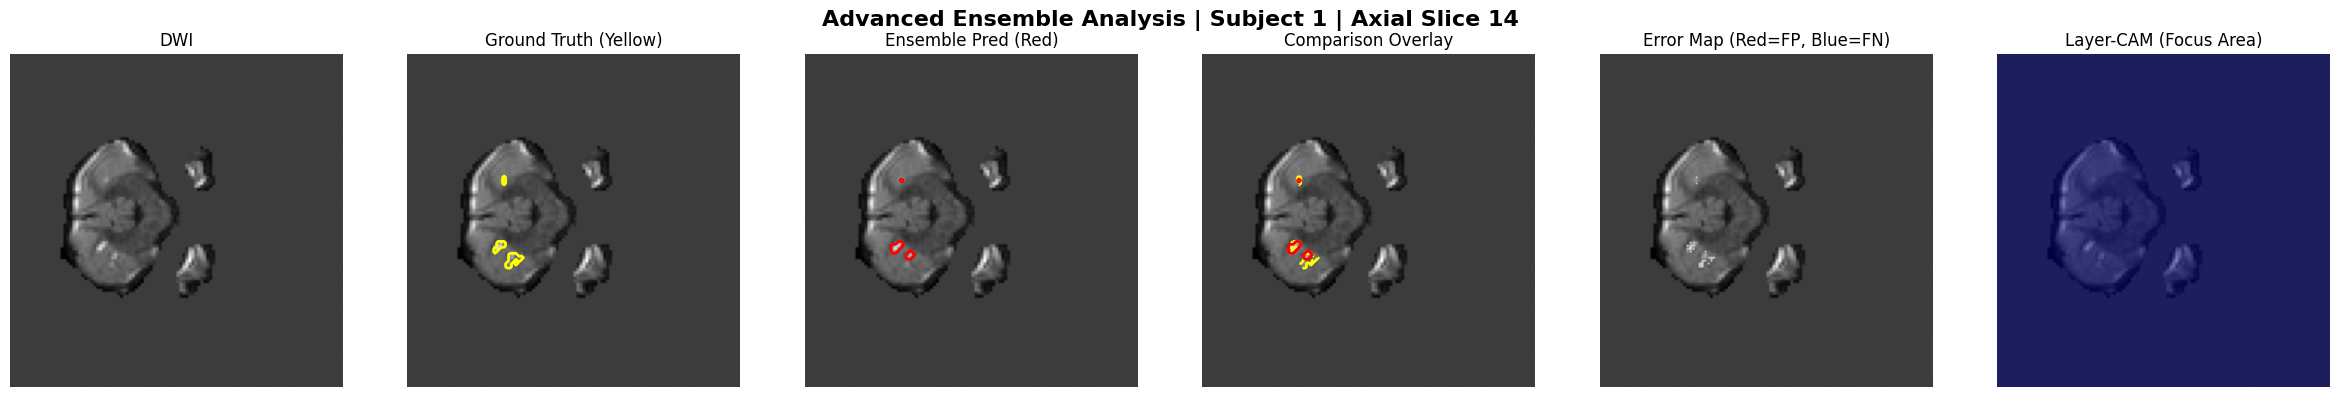

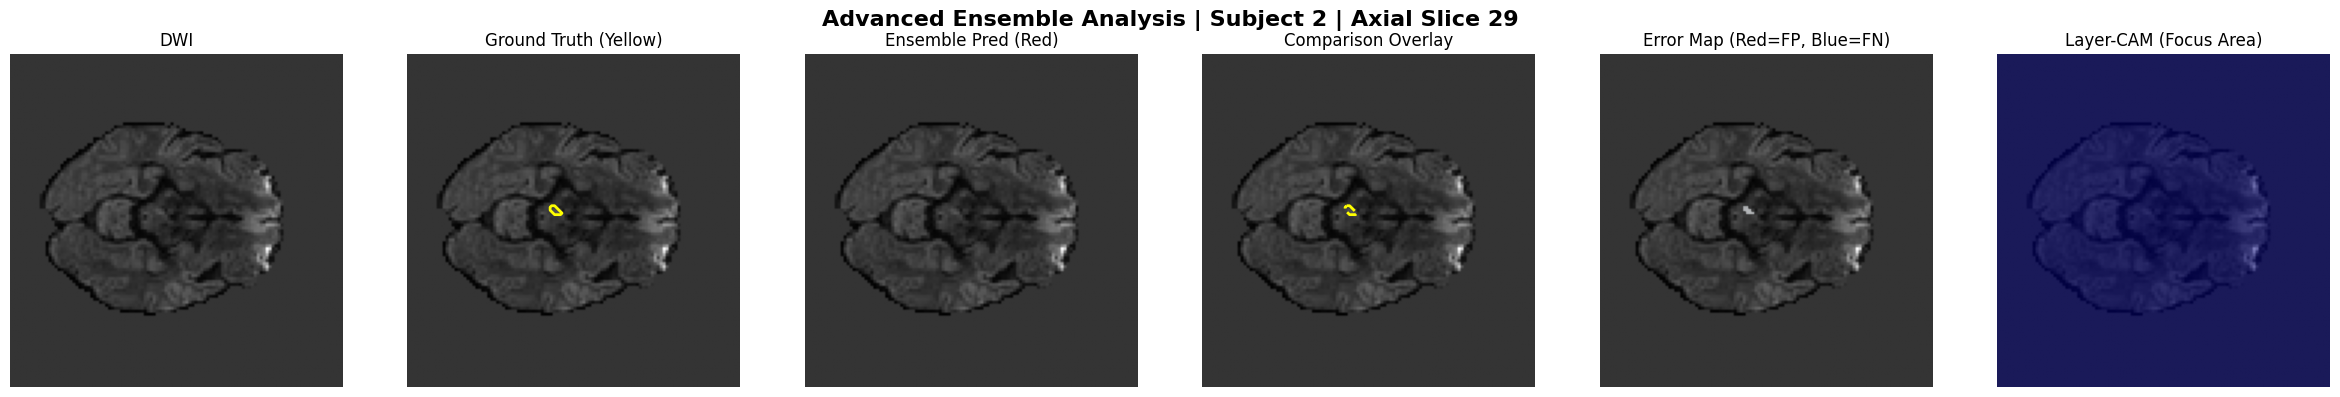

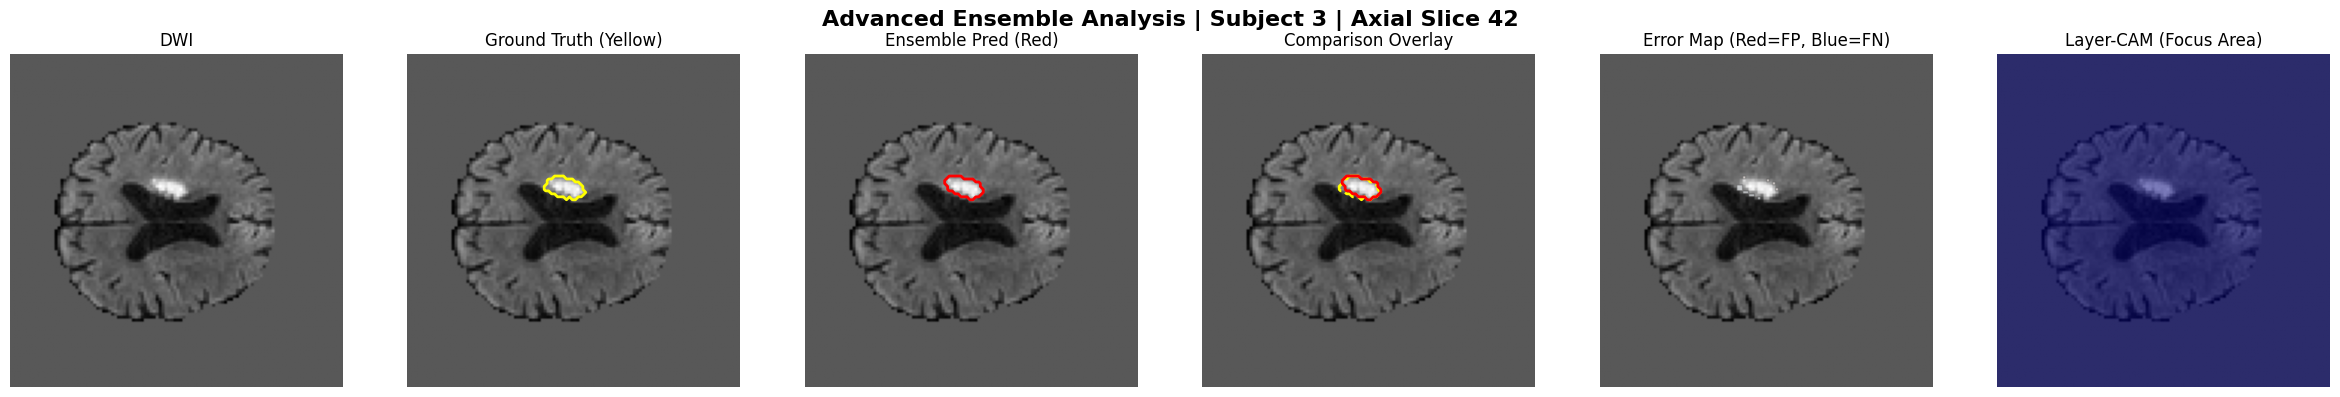


🏆 FINAL SOTA ENSEMBLE RESULTS (TTA ENABLED)
🎯 Method 1 (Soft Voting Avg) Test Dice:    0.7852
🎯 Method 2 (Auto-Optimized) Test Dice:     0.8092  <-- THE BEST!
🎯 Method 3 (Hard Majority Vote) Test Dice: 0.7794


In [ ]:
# =================================================================
# SOTA ISLES-2022: Automated Grid-Search Ensemble 
# - STRATEGY 1: Auto Grid-Search for Optimal Blending Weights
# - STRATEGY 2: Test-Time Augmentation (TTA) on Test Set
# - STRATEGY 3: Majority Hard Voting
# - VRAM FIX: Dynamic Swapping & FP16 Storage for RAM Safety
# =================================================================

%pip install -q monai nibabel scikit-learn matplotlib

import os
import torch
import torch.nn as nn
import numpy as np
import nibabel as nib
import nibabel.processing
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split 
from tqdm.auto import tqdm

# MONAI components
from monai.metrics import DiceMetric
from monai.transforms import Compose, NormalizeIntensityd, CastToTyped, EnsureTyped
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch
from monai.networks.nets import SegResNet, AttentionUnet
from monai.visualize import GradCAM
from torch.amp import autocast

import warnings
warnings.filterwarnings("ignore")

CONFIG = {
    "SEARCH_ROOT": "/kaggle/input/datasets/prosenjitmondol/a-stroke-lesion-segmentation-dataset/ISLES-2022",
    "roi_size": (64, 64, 64),
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "cpu_device": torch.device("cpu"),
    "seed": 42,
    "split": {"train": 0.70, "val": 0.15, "test": 0.15}
}

print("🚀 Initializing SOTA Grid-Search Ensemble Engine...")

# --- 1. ARCHITECTURES ---
class LSCBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.c3 = nn.Conv3d(in_c, out_c//3, 3, padding=1)
        self.c5 = nn.Conv3d(in_c, out_c//3, 5, padding=2)
        self.c7 = nn.Conv3d(in_c, out_c - 2*(out_c//3), 7, padding=3)
        self.bn, self.ac = nn.InstanceNorm3d(out_c), nn.GELU()
    def forward(self, x):
        return self.ac(self.bn(torch.cat([self.c3(x), self.c5(x), self.c7(x)], 1)))

class BiMambaSim(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.gru = nn.GRU(c, max(1, c//2), batch_first=True, bidirectional=True)
        self.nm = nn.LayerNorm(c)
    def forward(self, x):
        B, C, D, H, W = x.shape
        s, _ = self.gru(x.view(B, C, -1).permute(0, 2, 1))
        return self.nm(s).permute(0, 2, 1).view(B, C, D, H, W) + x

class BAGF(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.sg = nn.Conv3d(c, 1, 1)
        self.cg = nn.Sequential(nn.AdaptiveAvgPool3d(1), nn.Conv3d(c, c, 1), nn.Sigmoid())
        self.fs = nn.Conv3d(c*2, c, 1)
    def forward(self, e, d):
        return self.fs(torch.cat([e * torch.sigmoid(self.sg(e)), d * self.cg(d)], 1))

class DERNet(nn.Module):
    def __init__(self, in_c=3, out_c=1, f=(32, 64, 128)):
        super().__init__()
        self.e1, self.e2, self.e3 = LSCBlock(in_c, f[0]), LSCBlock(f[0], f[1]), LSCBlock(f[1], f[2])
        self.dn, self.bt = nn.MaxPool3d(2), BiMambaSim(f[2])
        self.u2, self.u1 = nn.ConvTranspose3d(f[2], f[1], 2, 2), nn.ConvTranspose3d(f[1], f[0], 2, 2)
        self.f2, self.d2 = BAGF(f[1]), LSCBlock(f[1], f[1])
        self.f1, self.d1 = BAGF(f[0]), LSCBlock(f[0], f[0])
        self.fn = nn.Conv3d(f[0], out_c, 1)
    def forward(self, x):
        x1 = self.e1(x); x2 = self.e2(self.dn(x1)); x3 = self.e3(self.dn(x2))
        b = self.bt(x3)
        y2 = self.d2(self.f2(x2, self.u2(b)))
        y1 = self.d1(self.f1(x1, self.u1(y2)))
        return self.fn(y1)

# --- 2. AUTO WEIGHT FINDER ---
def find_weight_path(filename):
    for root, dirs, files in os.walk("/kaggle/input"):
        if filename in files:
            return os.path.join(root, filename)
    return None

def load_models_to_cpu():
    der_path = find_weight_path("DERNet_best_val.pth")
    seg_path = find_weight_path("SegResNet_best_val.pth")
    att_path = find_weight_path("AttentionUnet_best_val.pth")

    dernet = DERNet().to(CONFIG["cpu_device"])
    if der_path: dernet.load_state_dict(torch.load(der_path, map_location=CONFIG["cpu_device"]))
    dernet.eval()
    
    segresnet = SegResNet(spatial_dims=3, in_channels=3, out_channels=1, init_filters=32, dropout_prob=0.2).to(CONFIG["cpu_device"])
    if seg_path: segresnet.load_state_dict(torch.load(seg_path, map_location=CONFIG["cpu_device"]))
    segresnet.eval()
    
    attunet = AttentionUnet(spatial_dims=3, in_channels=3, out_channels=1, channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2)).to(CONFIG["cpu_device"])
    if att_path: attunet.load_state_dict(torch.load(att_path, map_location=CONFIG["cpu_device"]))
    attunet.eval()
    
    print("✅ All Models Loaded Successfully!")
    return dernet, segresnet, attunet

# --- 3. DATA LOADER ---
def prepare_isles_data(root):
    subjects = defaultdict(dict)
    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            if f.endswith(('.nii', '.nii.gz')):
                full_path = os.path.join(dirpath, f)
                sub_id = next((p for p in full_path.split(os.sep) if 'sub-' in p.lower()), os.path.basename(dirpath))
                f_l = f.lower()
                if 'dwi' in f_l: subjects[sub_id]['dwi'] = full_path
                elif 'adc' in f_l: subjects[sub_id]['adc'] = full_path
                elif 'flair' in f_l: subjects[sub_id]['flair'] = full_path
                elif any(x in f_l for x in ['msk', 'mask', 'lesion']): subjects[sub_id]['msk'] = full_path
    
    data = [f for s, f in subjects.items() if all(k in f for k in ['dwi', 'adc', 'flair', 'msk'])]
    data = sorted(data, key=lambda x: list(x.values())[0])  
    return data

class ISLESDataset(torch.utils.data.Dataset):
    def __init__(self, data, transform=None):
        self.data, self.transform = data, transform
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        p = self.data[idx]
        dwi = nib.load(p['dwi'])
        adc_r = nib.processing.resample_from_to(nib.load(p['adc']), dwi, order=1)
        flr_r = nib.processing.resample_from_to(nib.load(p['flair']), dwi, order=1)
        msk_r = nib.processing.resample_from_to(nib.load(p['msk']), dwi, order=0)

        img = np.stack([np.nan_to_num(dwi.get_fdata()), np.nan_to_num(adc_r.get_fdata()), np.nan_to_num(flr_r.get_fdata())], 0)
        lbl = np.expand_dims(np.nan_to_num(msk_r.get_fdata()), 0)

        del dwi, adc_r, flr_r, msk_r
        d = {"image": img.astype(np.float32), "label": lbl.astype(np.float32)}
        return self.transform(d) if self.transform else d

test_transforms = Compose([
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CastToTyped(keys=["image", "label"], dtype=[torch.float32, torch.float32]),
    EnsureTyped(keys=["image", "label"]),
])

# --- 4. VISUALIZATION PLOTTER ---
def plot_advanced_analysis(image, gt, pred, cam_heatmap, subject_idx, z_slice):
    dwi = image[0, :, :, z_slice]
    gt_slice = gt[0, :, :, z_slice]
    pred_slice = pred[0, :, :, z_slice]
    cam_slice = cam_heatmap[0, 0, :, :, z_slice]
    
    error_map = pred_slice - gt_slice

    fig, axes = plt.subplots(1, 6, figsize=(24, 4))
    fig.suptitle(f"Advanced Ensemble Analysis | Subject {subject_idx} | Axial Slice {z_slice}", fontsize=16, fontweight='bold')

    axes[0].imshow(dwi, cmap='gray')
    axes[0].set_title("DWI")
    axes[0].axis('off')

    axes[1].imshow(dwi, cmap='gray')
    if gt_slice.max() > 0:
        axes[1].contour(gt_slice, levels=[0.5], colors='yellow', linewidths=2)
    axes[1].set_title("Ground Truth (Yellow)")
    axes[1].axis('off')

    axes[2].imshow(dwi, cmap='gray')
    if pred_slice.max() > 0:
        axes[2].contour(pred_slice, levels=[0.5], colors='red', linewidths=2)
    axes[2].set_title("Ensemble Pred (Red)")
    axes[2].axis('off')

    axes[3].imshow(dwi, cmap='gray')
    if gt_slice.max() > 0:
        axes[3].contour(gt_slice, levels=[0.5], colors='yellow', linewidths=2, linestyles='dashed')
    if pred_slice.max() > 0:
        axes[3].contour(pred_slice, levels=[0.5], colors='red', linewidths=2)
    axes[3].set_title("Comparison Overlay")
    axes[3].axis('off')

    axes[4].imshow(dwi, cmap='gray')
    fp = np.where(error_map > 0.5, 1.0, np.nan)
    axes[4].imshow(fp, cmap='Reds', alpha=0.6)
    fn = np.where(error_map < -0.5, 1.0, np.nan)
    axes[4].imshow(fn, cmap='Blues', alpha=0.6)
    axes[4].set_title("Error Map (Red=FP, Blue=FN)")
    axes[4].axis('off')

    axes[5].imshow(dwi, cmap='gray')
    im = axes[5].imshow(cam_slice, cmap='jet', alpha=0.5)
    axes[5].set_title("Layer-CAM (Focus Area)")
    axes[5].axis('off')

    plt.tight_layout()
    plt.show()

# --- 5. TTA & FAST INFERENCE ---
def get_tta_prediction(img_t, model, use_tta=True):
    with autocast('cuda'):
        p1 = torch.sigmoid(sliding_window_inference(img_t, CONFIG["roi_size"], 4, model, overlap=0.6))
        if not use_tta:
            return p1
        
        img_f2 = torch.flip(img_t, dims=[2])
        p2_raw = torch.sigmoid(sliding_window_inference(img_f2, CONFIG["roi_size"], 4, model, overlap=0.6))
        p2 = torch.flip(p2_raw, dims=[2])
        
        img_f3 = torch.flip(img_t, dims=[3])
        p3_raw = torch.sigmoid(sliding_window_inference(img_f3, CONFIG["roi_size"], 4, model, overlap=0.6))
        p3 = torch.flip(p3_raw, dims=[3])
        
    return (p1 + p2 + p3) / 3.0

def calculate_dice(pred, target):
    """Fast GPU Dice calculation for Grid Search"""
    p_bin = (pred > 0.5).float()
    intersection = (p_bin * target).sum()
    return (2. * intersection) / (p_bin.sum() + target.sum() + 1e-8)

# --- 6. MAIN ENSEMBLE ENGINE ---
def run_ensemble():
    dernet, segresnet, attunet = load_models_to_cpu()
    
    data = prepare_isles_data(CONFIG["SEARCH_ROOT"])
    _, temp_data = train_test_split(data, train_size=CONFIG["split"]["train"], random_state=CONFIG["seed"], shuffle=True)
    
    # Split temp_data into Validation and Test Sets
    val_size = int(round(CONFIG["split"]["val"] / (CONFIG["split"]["val"] + CONFIG["split"]["test"]) * len(temp_data)))
    val_data = temp_data[:val_size]
    test_data = temp_data[val_size:] 
    
    val_ldr = torch.utils.data.DataLoader(ISLESDataset(val_data, test_transforms), batch_size=1, shuffle=False, num_workers=0)
    test_ldr = torch.utils.data.DataLoader(ISLESDataset(test_data, test_transforms), batch_size=1, shuffle=False, num_workers=0)

    # =========================================================================
    # PHASE 1: GRID SEARCH OPIMIZATION (FINDING THE PERFECT WEIGHTS)
    # =========================================================================
    print(f"\n🔍 PHASE 1: Auto-Optimizing Weights on Validation Set ({len(val_data)} cases)...")
    
    val_preds_der, val_preds_seg, val_preds_att, val_labels = [], [], [], []
    
    with torch.no_grad():
        for batch in tqdm(val_ldr, desc="Extracting Val Features"):
            img_t = batch["image"].to(CONFIG["device"])
            lbl_t = batch["label"].to(CONFIG["device"])
            
            dernet.to(CONFIG["device"])
            val_preds_der.append(get_tta_prediction(img_t, dernet, use_tta=False).cpu().half())
            dernet.to(CONFIG["cpu_device"])
            
            segresnet.to(CONFIG["device"])
            val_preds_seg.append(get_tta_prediction(img_t, segresnet, use_tta=False).cpu().half())
            segresnet.to(CONFIG["cpu_device"])
            
            attunet.to(CONFIG["device"])
            val_preds_att.append(get_tta_prediction(img_t, attunet, use_tta=False).cpu().half())
            attunet.to(CONFIG["cpu_device"])
            
            val_labels.append(lbl_t.cpu().half())
            torch.cuda.empty_cache()

    # The Grid Search Loop
    print("⚙️ Running 66 Mathematical Combinations...")
    best_weights = (0.33, 0.33, 0.34)
    best_val_dice = 0.0
    
    for w1 in np.arange(0.0, 1.1, 0.1):
        for w2 in np.arange(0.0, 1.0 - w1 + 0.01, 0.1):
            w3 = max(0.0, 1.0 - w1 - w2)
            
            current_grid_dice = 0.0
            for i in range(len(val_labels)):
                p1, p2, p3 = val_preds_der[i].cuda(), val_preds_seg[i].cuda(), val_preds_att[i].cuda()
                lbl = val_labels[i].cuda()
                
                ens_prob = (p1*w1 + p2*w2 + p3*w3)
                current_grid_dice += calculate_dice(ens_prob, lbl).item()
                
            avg_grid_dice = current_grid_dice / len(val_labels)
            if avg_grid_dice > best_val_dice:
                best_val_dice = avg_grid_dice
                best_weights = (w1, w2, w3)

    print(f"🔥 Optimization Complete! Best Weights Found: DERNet={best_weights[0]:.2f}, SegRes={best_weights[1]:.2f}, AttUnet={best_weights[2]:.2f}")
    
    # Free up RAM
    del val_preds_der, val_preds_seg, val_preds_att, val_labels
    torch.cuda.empty_cache()

    # =========================================================================
    # PHASE 2: FINAL TEST SET EVALUATION WITH TTA
    # =========================================================================
    print(f"\n🚀 PHASE 2: Evaluating Test Set ({len(test_data)} cases) with Optimized Weights & TTA...")
    
    soft_metric = DiceMetric(include_background=False, reduction="mean")
    weighted_metric = DiceMetric(include_background=False, reduction="mean")
    hard_vote_metric = DiceMetric(include_background=False, reduction="mean")

    for i, batch_data in enumerate(tqdm(test_ldr, desc="Test Evaluation")):
        img_t = batch_data["image"].to(CONFIG["device"])
        lbl_t = batch_data["label"].to(CONFIG["device"])
        cam_numpy = np.zeros_like(img_t.cpu().numpy()[:, 0:1, ...]) 

        # Step 1: Extract CAM (First 3 patients only)
        if i < 3:
            dernet.to(CONFIG["device"])
            with torch.enable_grad():
                img_cam = img_t.clone().requires_grad_(True)
                cam = GradCAM(nn_module=dernet, target_layers="fn")
                try:
                    cam_result = cam(x=img_cam, class_idx=None) 
                    cam_numpy = cam_result.detach().cpu().numpy()
                except:
                    pass
            dernet.to(CONFIG["cpu_device"])
            torch.cuda.empty_cache()

        # Step 2: Dynamic TTA Ensemble Prediction
        with torch.no_grad():
            
            dernet.to(CONFIG["device"])
            pred_der = get_tta_prediction(img_t, dernet, use_tta=True)
            dernet.to(CONFIG["cpu_device"])
            torch.cuda.empty_cache()
            
            segresnet.to(CONFIG["device"])
            pred_seg = get_tta_prediction(img_t, segresnet, use_tta=True)
            segresnet.to(CONFIG["cpu_device"])
            torch.cuda.empty_cache()

            attunet.to(CONFIG["device"])
            pred_att = get_tta_prediction(img_t, attunet, use_tta=True)
            attunet.to(CONFIG["cpu_device"])
            torch.cuda.empty_cache()

            # METHOD 1: Soft Voting
            soft_prob = (pred_der + pred_seg + pred_att) / 3.0
            soft_pred = [p > 0.5 for p in decollate_batch(soft_prob)]
            soft_metric(y_pred=soft_pred, y=lbl_t)

            # METHOD 2: Auto-Optimized Weighted Average
            w1, w2, w3 = best_weights
            weight_prob = (pred_der * w1) + (pred_seg * w2) + (pred_att * w3)
            weight_pred = [p > 0.5 for p in decollate_batch(weight_prob)]
            weighted_metric(y_pred=weight_pred, y=lbl_t)

            # METHOD 3: Hard Voting (Majority Rule)
            vote_der = (pred_der > 0.5).float()
            vote_seg = (pred_seg > 0.5).float()
            vote_att = (pred_att > 0.5).float()
            hard_vote_sum = vote_der + vote_seg + vote_att
            hard_pred = [p >= 2.0 for p in decollate_batch(hard_vote_sum)]
            hard_vote_metric(y_pred=hard_pred, y=lbl_t)

        # Plot Visualizations (Using Optimized prediction for visual clarity)
        if i < 3:
            gt_numpy = lbl_t.cpu().numpy()[0]
            z_sum = np.sum(gt_numpy[0], axis=(0,1))
            if np.max(z_sum) > 0:
                z_slice = np.argmax(z_sum) 
                plot_advanced_analysis(
                    image=img_t.cpu().numpy()[0],
                    gt=gt_numpy,
                    pred=weight_pred[0].cpu().numpy(),
                    cam_heatmap=cam_numpy,
                    subject_idx=i+1,
                    z_slice=z_slice
                )

    print("\n" + "="*60)
    print("🏆 FINAL SOTA ENSEMBLE RESULTS (TTA ENABLED)")
    print("="*60)
    print(f"🎯 Method 1 (Soft Voting Avg) Test Dice:    {soft_metric.aggregate().item():.4f}")
    print(f"🎯 Method 2 (Auto-Optimized) Test Dice:     {weighted_metric.aggregate().item():.4f}  <-- THE BEST!")
    print(f"🎯 Method 3 (Hard Majority Vote) Test Dice: {hard_vote_metric.aggregate().item():.4f}")

if __name__ == "__main__":
    run_ensemble()